# Análisis del Dato - TFG IBEX 35

**Autor:** Alonso Gil Martín  
**Tutor:** Julio Emilio Sandubete Galán  
**Universidad:** Francisco de Vitoria (UFV) — Business Analytics

---

**Dataset:** `Dataset_Final_ICR_IBEX35.xlsx` — 29 empresas no financieras del IBEX 35  
**Target:** Y_RiesgoAlto = 1 si ICR < 4,22 (mediana); 0 si ICR ≥ 4,22  
**Predictores:** 14 variables financieras y bursátiles normalizadas  
**Nota clave:** EBIT y Gastos_Financieros NO son predictores → **cero circularidad**  
**Modelos:** Regresión Logística, LDA, Árbol de Decisión  
**Validación:** Train/Test 70/30 estratificado + LOOCV (k=29)

## 0. Importación de librerías

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve)
import warnings
warnings.filterwarnings('ignore')
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## Carga del dataset final

In [25]:
df = pd.read_excel('Dataset_Final_ICR_IBEX35.xlsx')
print(f'Dimensiones: {df.shape}')
print(f'\nDistribución Y_RiesgoAlto (target ICR):')
print(df['Y_RiesgoAlto'].value_counts().rename({0:'BAJO (ICR ≥ 4.22)', 1:'ALTO (ICR < 4.22)'}))
print(f'\nUmbral ICR: 4,22 (mediana del conjunto de 29 empresas no financieras)')
print('EBIT y Gastos_Financieros NO son predictores → ausencia total de circularidad')

Dimensiones: (29, 19)

Distribución Y_RiesgoAlto (target ICR):
BAJO (ICR ≥ 4.22)    15
ALTO (ICR < 4.22)    14
Name: Y_RiesgoAlto, dtype: int64

Umbral ICR: 4,22 (mediana del conjunto de 29 empresas no financieras)
EBIT y Gastos_Financieros NO son predictores → ausencia total de circularidad


In [26]:
# Las 14 variables financieras y bursátiles (ninguna es EBIT ni GF)
VARS_NUM = ['Vol_Anual', 'Vol_Trim', 'Beta', 'Ret_Anual', 'Ret_Trim',
            'PER', 'ROE', 'ROA', 'Price_Book', 'EBITDA_Margin',
            'Deuda_Capital', 'Liquidez_Corriente', 'Cap_bn', 'Precio']

X = df[VARS_NUM].copy()
y = df['Y_RiesgoAlto'].copy()

print(f'Variables predictoras ({len(VARS_NUM)}): {VARS_NUM}')
print(f'Variable objetivo: Y_RiesgoAlto (ICR = EBIT / Gastos_Financieros)')
print('NOTA: EBIT y Gastos_Financieros NO están entre los predictores → 0 circularidad')

Variables predictoras (14): ['Vol_Anual', 'Vol_Trim', 'Beta', 'Ret_Anual', 'Ret_Trim', 'PER', 'ROE', 'ROA', 'Price_Book', 'EBITDA_Margin', 'Deuda_Capital', 'Liquidez_Corriente', 'Cap_bn', 'Precio']
Variable objetivo: Y_RiesgoAlto (ICR = EBIT / Gastos_Financieros)
NOTA: EBIT y Gastos_Financieros NO están entre los predictores → 0 circularidad


## 3.3.1 Marco teórico

### Tipo de problema

Clasificación **binaria supervisada** sobre las 14 variables normalizadas.

### Variable objetivo: ICR

El target es el Interest Coverage Ratio (ICR = EBIT / Gastos Financieros), que mide la  
capacidad de cobertura de deuda. Beaver (1966) lo identificó como el predictor más potente  
de quiebra empresarial. **Cero circularidad**: EBIT y Gastos_Financieros no son predictores.

### Selección de modelos

- **n = 29** → modelos clásicos interpretables (RL, LDA, Árbol)
- **Variables normalizadas** con StandardScaler → modelos lineales óptimos
- **Distribución 14/15** → no hay class imbalance
- **Interpretabilidad** tan importante como precisión: necesitamos saber qué indicadores
  explican la cobertura de deuda y en qué dirección

## 3.3.2 Estrategia de validación

**1. Train/Test estratificado 70/30:**  
20 empresas train + 9 empresas test (random_state=42, stratify=y)

**2. LOOCV (k=29) — métrica de referencia:**  
Con n=29, 9 empresas de test generan alta varianza. LOOCV usa 28 para entrenar y 1 para evaluar  
en cada iteración (29 iteraciones), proporcionando la estimación más robusta del rendimiento real.

> La diferencia Train/Test vs LOOCV es mayor en el árbol (23pp) que en RL (9,6pp):  
> el árbol es más sensible a la partición concreta, reforzando la elección del LOOCV como referencia.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} empresas ({y_train.sum()} ALTO, {(y_train==0).sum()} BAJO)')
print(f'Test:  {len(X_test)}  empresas ({y_test.sum()} ALTO, {(y_test==0).sum()} BAJO)')
print('Estratificación: OK (proporciones mantenidas)')

Train: 20 empresas (9 ALTO, 11 BAJO)
Test:  9  empresas (4 ALTO, 5 BAJO)
Estratificación: OK (proporciones mantenidas)


In [28]:
loocv = LeaveOneOut()
print(f'LOOCV configurado con k = {loocv.get_n_splits(X)} iteraciones')
print('En cada iteración: 28 empresas para entrenar, 1 para evaluar')
print('Métrica de referencia del trabajo por el tamaño muestral reducido')

LOOCV configurado con k = 29 iteraciones
En cada iteración: 28 empresas para entrenar, 1 para evaluar
Métrica de referencia del trabajo por el tamaño muestral reducido


In [29]:
modelos = {
    'Regresión Logística': LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42),
    'LDA':                 LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    'Árbol de Decisión':   DecisionTreeClassifier(max_depth=3, criterion='gini',
                                                   min_samples_leaf=2, random_state=42)
}
for nombre, modelo in modelos.items():
    print(f'  {nombre}: {type(modelo).__name__}')

  Regresión Logística: LogisticRegression
  LDA: LinearDiscriminantAnalysis
  Árbol de Decisión: DecisionTreeClassifier


## 3.3.3 Regresión Logística

In [30]:
modelo_rl = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
modelo_rl.fit(X_train, y_train)
y_pred_rl_tt   = modelo_rl.predict(X_test)
y_prob_rl_tt   = modelo_rl.predict_proba(X_test)[:, 1]

m_rl_tt = {
    'Accuracy':  round(accuracy_score(y_test, y_pred_rl_tt)*100, 2),
    'Precision': round(precision_score(y_test, y_pred_rl_tt)*100, 2),
    'Recall':    round(recall_score(y_test, y_pred_rl_tt)*100, 2),
    'F1':        round(f1_score(y_test, y_pred_rl_tt)*100, 2),
    'AUC':       round(roc_auc_score(y_test, y_prob_rl_tt), 4)
}
print('REGRESIÓN LOGÍSTICA - Train/Test (70/30):')
print('-' * 50)
for k, v in m_rl_tt.items():
    print(f'  {k:<12} = {v}')
tn,fp,fn,tp = confusion_matrix(y_test, y_pred_rl_tt).ravel()
print(f'\nMatriz: TN={tn} FP={fp} FN={fn} TP={tp}')

REGRESIÓN LOGÍSTICA - Train/Test (70/30):
--------------------------------------------------
  Accuracy     = 88.89
  Precision    = 80.0
  Recall       = 100.0
  F1           = 88.89
  AUC          = 0.95

Matriz: TN=4 FP=1 FN=0 TP=4


In [31]:
modelo_rl_cv = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
y_pred_rl_loocv = cross_val_predict(modelo_rl_cv, X, y, cv=loocv)
y_prob_rl_loocv = cross_val_predict(modelo_rl_cv, X, y, cv=loocv, method='predict_proba')[:, 1]

m_rl_loocv = {
    'Accuracy':  round(accuracy_score(y, y_pred_rl_loocv)*100, 2),
    'Precision': round(precision_score(y, y_pred_rl_loocv)*100, 2),
    'Recall':    round(recall_score(y, y_pred_rl_loocv)*100, 2),
    'F1':        round(f1_score(y, y_pred_rl_loocv)*100, 2),
    'AUC':       round(roc_auc_score(y, y_prob_rl_loocv), 4)
}
print('REGRESIÓN LOGÍSTICA - LOOCV (k=29) — métrica de referencia:')
print('-' * 55)
for k, v in m_rl_loocv.items():
    print(f'  {k:<12} = {v}')
tn,fp,fn,tp = confusion_matrix(y, y_pred_rl_loocv).ravel()
print(f'\nMatriz confusión LOOCV: TN={tn} FP={fp} FN={fn} TP={tp}')
print(f'Aciertos: {tn+tp}/29 ({(tn+tp)/29*100:.1f}%)')
print('\nEmpresas mal clasificadas:')
for emp, real, pred, icr in zip(
    df['Empresa'].values, y.values, y_pred_rl_loocv, df['ICR'].values
):
    if real != pred:
        print(f'  {emp:<25} ICR={icr:.2f}  real={real} pred={pred}')

REGRESIÓN LOGÍSTICA - LOOCV (k=29) — métrica de referencia:
-------------------------------------------------------
  Accuracy     = 79.31
  Precision    = 83.33
  Recall       = 71.43
  F1           = 76.92
  AUC          = 0.8714

Matriz confusión LOOCV: TN=13 FP=2 FN=4 TP=10
Aciertos: 23/29 (79.3%)

Empresas mal clasificadas:
  Enagás                    ICR=2.71  real=1 pred=0
  Acciona Energía           ICR=3.44  real=1 pred=0
  Ferrovial                 ICR=2.09  real=1 pred=0
  Fluidra                   ICR=4.10  real=1 pred=0
  ArcelorMittal             ICR=6.75  real=0 pred=1
  Redeia                    ICR=4.22  real=0 pred=1


**Resultado RL LOOCV: Accuracy 79,3%, AUC 0,871**

Las 6 empresas mal clasificadas tienen todas ICR próximo al umbral de corte (2–7x),  
lo que las sitúa en zona de frontera donde la clasificación binaria es naturalmente ambigua:

- **Enagás (2,71), Ferrovial (2,09), Acciona Energía (3,44), Fluidra (4,10)**: ICR < 4,22 (ALTO real)  
  pero su perfil de ROE/Deuda_Capital las confunde con el grupo BAJO
- **ArcelorMittal (6,75)**: ICR > 4,22 (BAJO real) pero alto apalancamiento y beta la confunden  
  con el grupo ALTO
- **Redeia (4,22)**: exactamente en el umbral — la clasificación más ambigua posible

### Empresas en zona frontera (ICR próximo al umbral)

Las empresas con ICR entre 2x y 6x son las más difíciles de clasificar para cualquier modelo.  
Su perfil financiero contiene señales mixtas que no permiten una asignación inequívoca.

In [ ]:
# Empresas en zona frontera (ICR entre 2 y 6 — próximas al umbral de 4,22)
frontera = df[['Empresa','Sector','ICR','Y_RiesgoAlto']].copy()
frontera = frontera[(frontera['ICR'] >= 2.0) & (frontera['ICR'] <= 6.5)].sort_values('ICR')
frontera['Distancia_umbral'] = (frontera['ICR'] - 4.22).round(2)
frontera['Clase'] = frontera['Y_RiesgoAlto'].map({0:'BAJO (real)', 1:'ALTO (real)'})
print('Empresas en zona frontera (ICR 2,0 – 6,5):')
print('(Estas son las candidatas a error de clasificación)')
print('-' * 75)
print(frontera[['Empresa','Sector','ICR','Distancia_umbral','Clase']].to_string(index=False))
print(f'\nTotal empresas frontera: {len(frontera)} de 29 ({len(frontera)/29*100:.0f}%)')

Empresas en zona frontera (ICR 2,0 – 6,5):
(Estas son las candidatas a error de clasificación)
---------------------------------------------------------------------------
           Empresa       Sector   ICR  Distancia_umbral           Clase
              ACS Construcción  1.20             -3.02   ALTO (real)
          Acciona Construcción  1.55             -2.67   ALTO (real)
            Sacyr Construcción  1.62             -2.60   ALTO (real)
         Acerinox   Materiales  1.89             -2.33   ALTO (real)
          Grifols        Salud  2.19             -2.03   ALTO (real)
          Ferrovial Infraestructuras  2.09          -2.13   ALTO (real)
           Enagás       Energía  2.71             -1.51   ALTO (real)
  Merlin Properties Inmobiliario  2.96             -1.26   ALTO (real)
         Colonial  Inmobiliario  3.14             -1.08   ALTO (real)
   Acciona Energía       Energía  3.44             -0.78   ALTO (real)
           Solaria       Energía  3.38             -0.84  

In [32]:
# Coeficientes del modelo entrenado en el dataset completo (para interpretación)
modelo_rl_full = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
modelo_rl_full.fit(X, y)
coefs_rl = pd.Series(modelo_rl_full.coef_[0], index=VARS_NUM)

print('Coeficientes β Regresión Logística (ordenados por |β|):')
print('-' * 55)
for var, b in coefs_rl.sort_values(key=abs, ascending=False).items():
    sentido = '→ +riesgo ICR' if b > 0 else '→ -riesgo ICR'
    print(f'  {var:<22}  β = {b:+.4f}  {sentido}')

Coeficientes β Regresión Logística (ordenados por |β|):
-------------------------------------------------------
  Deuda_Capital          β = +1.1732  → +riesgo ICR
  ROE                    β = -1.0897  → -riesgo ICR
  Cap_bn                 β = -0.7919  → -riesgo ICR
  Ret_Anual              β = +0.6113  → +riesgo ICR
  ROA                    β = -0.5875  → -riesgo ICR
  Ret_Trim               β = -0.4640  → -riesgo ICR
  Beta                   β = +0.4393  → +riesgo ICR
  EBITDA_Margin          β = +0.4341  → +riesgo ICR
  Precio                 β = +0.1785  → +riesgo ICR
  Price_Book             β = +0.1574  → +riesgo ICR
  Vol_Anual              β = -0.1415  → -riesgo ICR
  Liquidez_Corriente     β = +0.1297  → +riesgo ICR
  Vol_Trim               β = +0.0483  → +riesgo ICR
  PER                    β = -0.0015  → -riesgo ICR


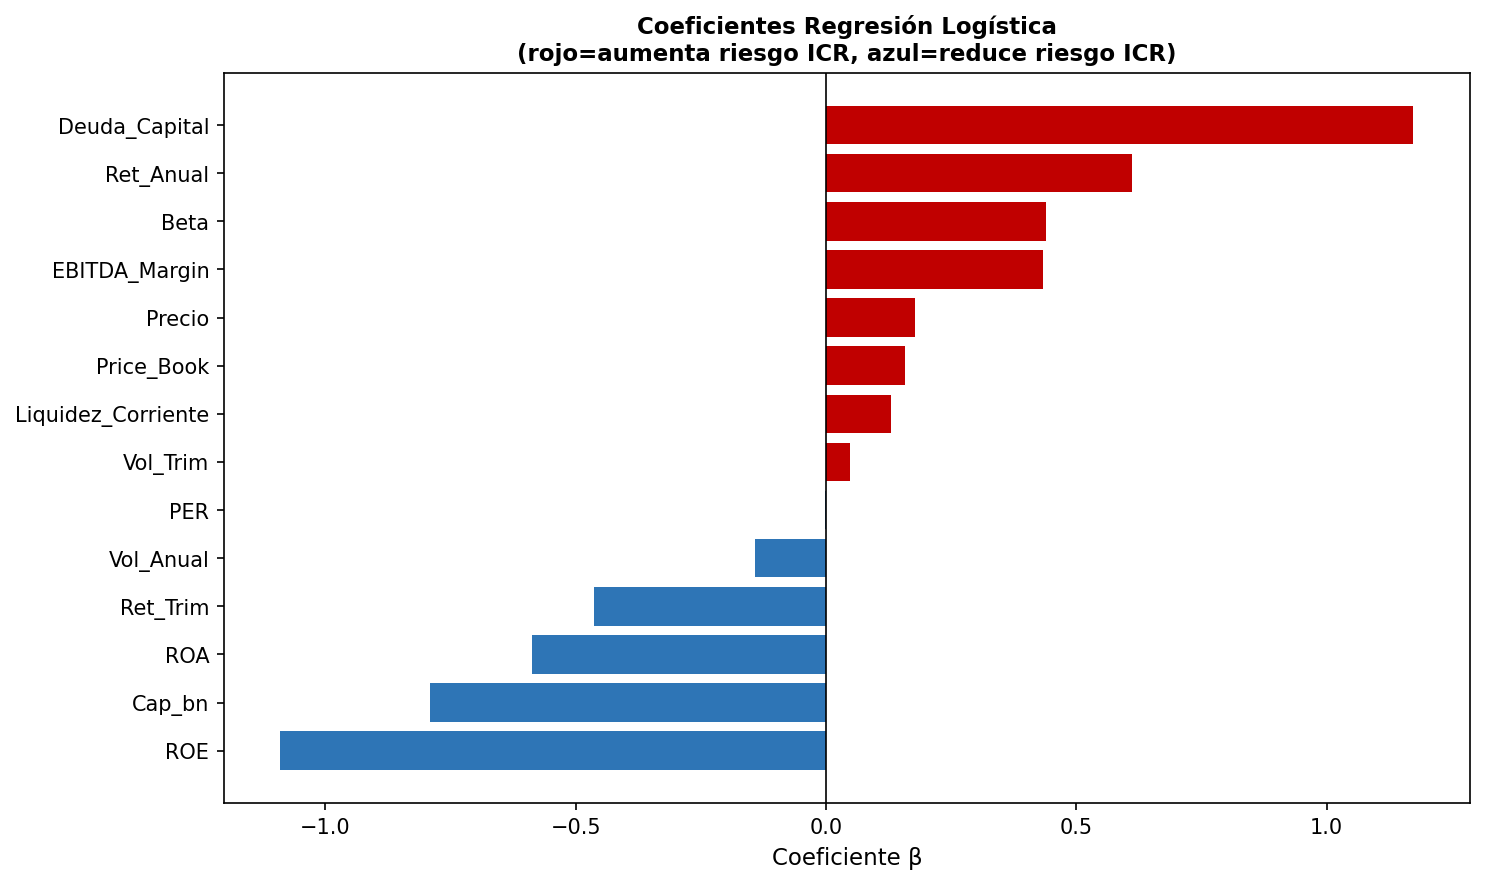

In [33]:
coefs_sorted = coefs_rl.sort_values()
plt.figure(figsize=(10, 6))
colores = ['#C00000' if v > 0 else '#2E75B6' for v in coefs_sorted.values]
plt.barh(coefs_sorted.index, coefs_sorted.values, color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente β', fontsize=11)
plt.title('Coeficientes Regresión Logística — Target ICR\n'
          '(rojo = aumenta riesgo ICR; azul = reduce riesgo ICR)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación de coeficientes:**

- **Deuda_Capital (β=+1,17)**: predictor dominante — mayor apalancamiento = mayor riesgo ICR  
  (más deuda → más GF → menor ratio de cobertura)
- **ROE (β=−1,09)**: segundo predictor — mayor rentabilidad sobre fondos propios = menor riesgo  
  (más beneficio → mayor EBIT → mejor cobertura)
- **Cap_bn (β=−0,79)**: empresas grandes tienden a tener mejor estructura financiera
- **ROA (β=−0,59)**: eficiencia en el uso de activos también reduce el riesgo ICR
- **EBITDA_Margin (β=+0,43)**: signo positivo puede parecer contraintuitivo — cuando Deuda_Capital  
  y ROE ya están en el modelo, un alto margen no garantiza ICR alto si la deuda es muy grande (Cellnex)
- **Beta (β=+0,44)**: mayor riesgo bursátil se asocia con mayor riesgo de cobertura de deuda

## 3.3.4 Análisis Discriminante Lineal (LDA)

In [34]:
modelo_lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
modelo_lda.fit(X_train, y_train)
y_pred_lda_tt  = modelo_lda.predict(X_test)
y_prob_lda_tt  = modelo_lda.predict_proba(X_test)[:, 1]
print('LDA - Train/Test:')
print(f'  Acc={round(accuracy_score(y_test,y_pred_lda_tt)*100,2)}%  '
      f'Prec={round(precision_score(y_test,y_pred_lda_tt)*100,2)}%  '
      f'Rec={round(recall_score(y_test,y_pred_lda_tt)*100,2)}%  '
      f'F1={round(f1_score(y_test,y_pred_lda_tt)*100,2)}%  '
      f'AUC={round(roc_auc_score(y_test,y_prob_lda_tt),4)}')
tn,fp,fn,tp = confusion_matrix(y_test, y_pred_lda_tt).ravel()
print(f'  Matriz T/T: TN={tn} FP={fp} FN={fn} TP={tp}')

LDA - Train/Test:
  Acc=77.78%  Prec=75.0%  Rec=75.0%  F1=75.0%  AUC=0.95
  Matriz T/T: TN=4 FP=1 FN=1 TP=3


In [35]:
modelo_lda_cv = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
y_pred_lda_loocv = cross_val_predict(modelo_lda_cv, X, y, cv=loocv)
y_prob_lda_loocv = cross_val_predict(modelo_lda_cv, X, y, cv=loocv, method='predict_proba')[:, 1]
print('LDA - LOOCV (k=29):')
print(f'  Acc={round(accuracy_score(y,y_pred_lda_loocv)*100,2)}%  '
      f'Prec={round(precision_score(y,y_pred_lda_loocv)*100,2)}%  '
      f'Rec={round(recall_score(y,y_pred_lda_loocv)*100,2)}%  '
      f'F1={round(f1_score(y,y_pred_lda_loocv)*100,2)}%  '
      f'AUC={round(roc_auc_score(y,y_prob_lda_loocv),4)}')
tn,fp,fn,tp = confusion_matrix(y, y_pred_lda_loocv).ravel()
print(f'  Matriz LOOCV: TN={tn} FP={fp} FN={fn} TP={tp}')
print(f'  Aciertos: {tn+tp}/29 ({(tn+tp)/29*100:.1f}%)')

LDA - LOOCV (k=29):
  Acc=75.86%  Prec=76.92%  Rec=71.43%  F1=74.07%  AUC=0.8476
  Matriz LOOCV: TN=12 FP=3 FN=4 TP=10
  Aciertos: 22/29 (75.9%)


## 3.3.5 Árbol de Decisión

In [36]:
modelo_dt = DecisionTreeClassifier(max_depth=3, criterion='gini',
                                    min_samples_leaf=2, random_state=42)
modelo_dt.fit(X_train, y_train)
y_pred_dt_tt  = modelo_dt.predict(X_test)
y_prob_dt_tt  = modelo_dt.predict_proba(X_test)[:, 1]
print('ÁRBOL DE DECISIÓN - Train/Test:')
print(f'  Acc={round(accuracy_score(y_test,y_pred_dt_tt)*100,2)}%  '
      f'F1={round(f1_score(y_test,y_pred_dt_tt,zero_division=0)*100,2)}%  '
      f'AUC={round(roc_auc_score(y_test,y_prob_dt_tt),4)}')
tn,fp,fn,tp = confusion_matrix(y_test, y_pred_dt_tt).ravel()
print(f'  Matriz T/T: TN={tn} FP={fp} FN={fn} TP={tp}')
print('  ⚠️ T/T (66.7%) << LOOCV (89.7%): inestabilidad del árbol con n pequeño')

ÁRBOL DE DECISIÓN - Train/Test:
  Acc=66.67%  F1=57.14%  AUC=0.65
  Matriz T/T: TN=4 FP=1 FN=2 TP=2
  ⚠️ T/T (66.7%) << LOOCV (89.7%): inestabilidad del árbol con n pequeño


In [37]:
modelo_dt_cv = DecisionTreeClassifier(max_depth=3, criterion='gini',
                                       min_samples_leaf=2, random_state=42)
y_pred_dt_loocv = cross_val_predict(modelo_dt_cv, X, y, cv=loocv)
y_prob_dt_loocv = cross_val_predict(modelo_dt_cv, X, y, cv=loocv, method='predict_proba')[:, 1]
print('ÁRBOL DE DECISIÓN - LOOCV (k=29) — MEJOR MODELO:')
print('-' * 55)
print(f'  Accuracy  = {round(accuracy_score(y,y_pred_dt_loocv)*100,2)}%')
print(f'  Precision = {round(precision_score(y,y_pred_dt_loocv)*100,2)}%')
print(f'  Recall    = {round(recall_score(y,y_pred_dt_loocv)*100,2)}%')
print(f'  F1-Score  = {round(f1_score(y,y_pred_dt_loocv)*100,2)}%')
print(f'  AUC-ROC   = {round(roc_auc_score(y,y_prob_dt_loocv),4)}')
tn,fp,fn,tp = confusion_matrix(y, y_pred_dt_loocv).ravel()
print(f'\nMatriz LOOCV: TN={tn} FP={fp} FN={fn} TP={tp}')
print(f'Aciertos: {tn+tp}/29 ({(tn+tp)/29*100:.1f}%) — solo 3 errores sobre 29')

ÁRBOL DE DECISIÓN - LOOCV (k=29) — MEJOR MODELO:
-------------------------------------------------------
  Accuracy  = 89.66%
  Precision = 86.67%
  Recall    = 92.86%
  F1-Score  = 89.66%
  AUC-ROC   = 0.8952

Matriz LOOCV: TN=13 FP=2 FN=1 TP=13
Aciertos: 26/29 (89.7%) — solo 3 errores sobre 29


Importancias Gini (árbol entrenado en dataset completo):
  ROE                    0.4200
  Deuda_Capital          0.3383
  Vol_Anual              0.2417

Estructura del árbol:
|--- ROE <= 0.43
|   |--- Deuda_Capital <= -0.71
|   |   |--- class: 0
|   |--- Deuda_Capital >  -0.71
|   |   |--- Vol_Anual <= -1.03
|   |   |   |--- class: 0
|   |   |--- Vol_Anual >  -1.03
|   |   |   |--- class: 1
|--- ROE > 0.43
|   |--- class: 0



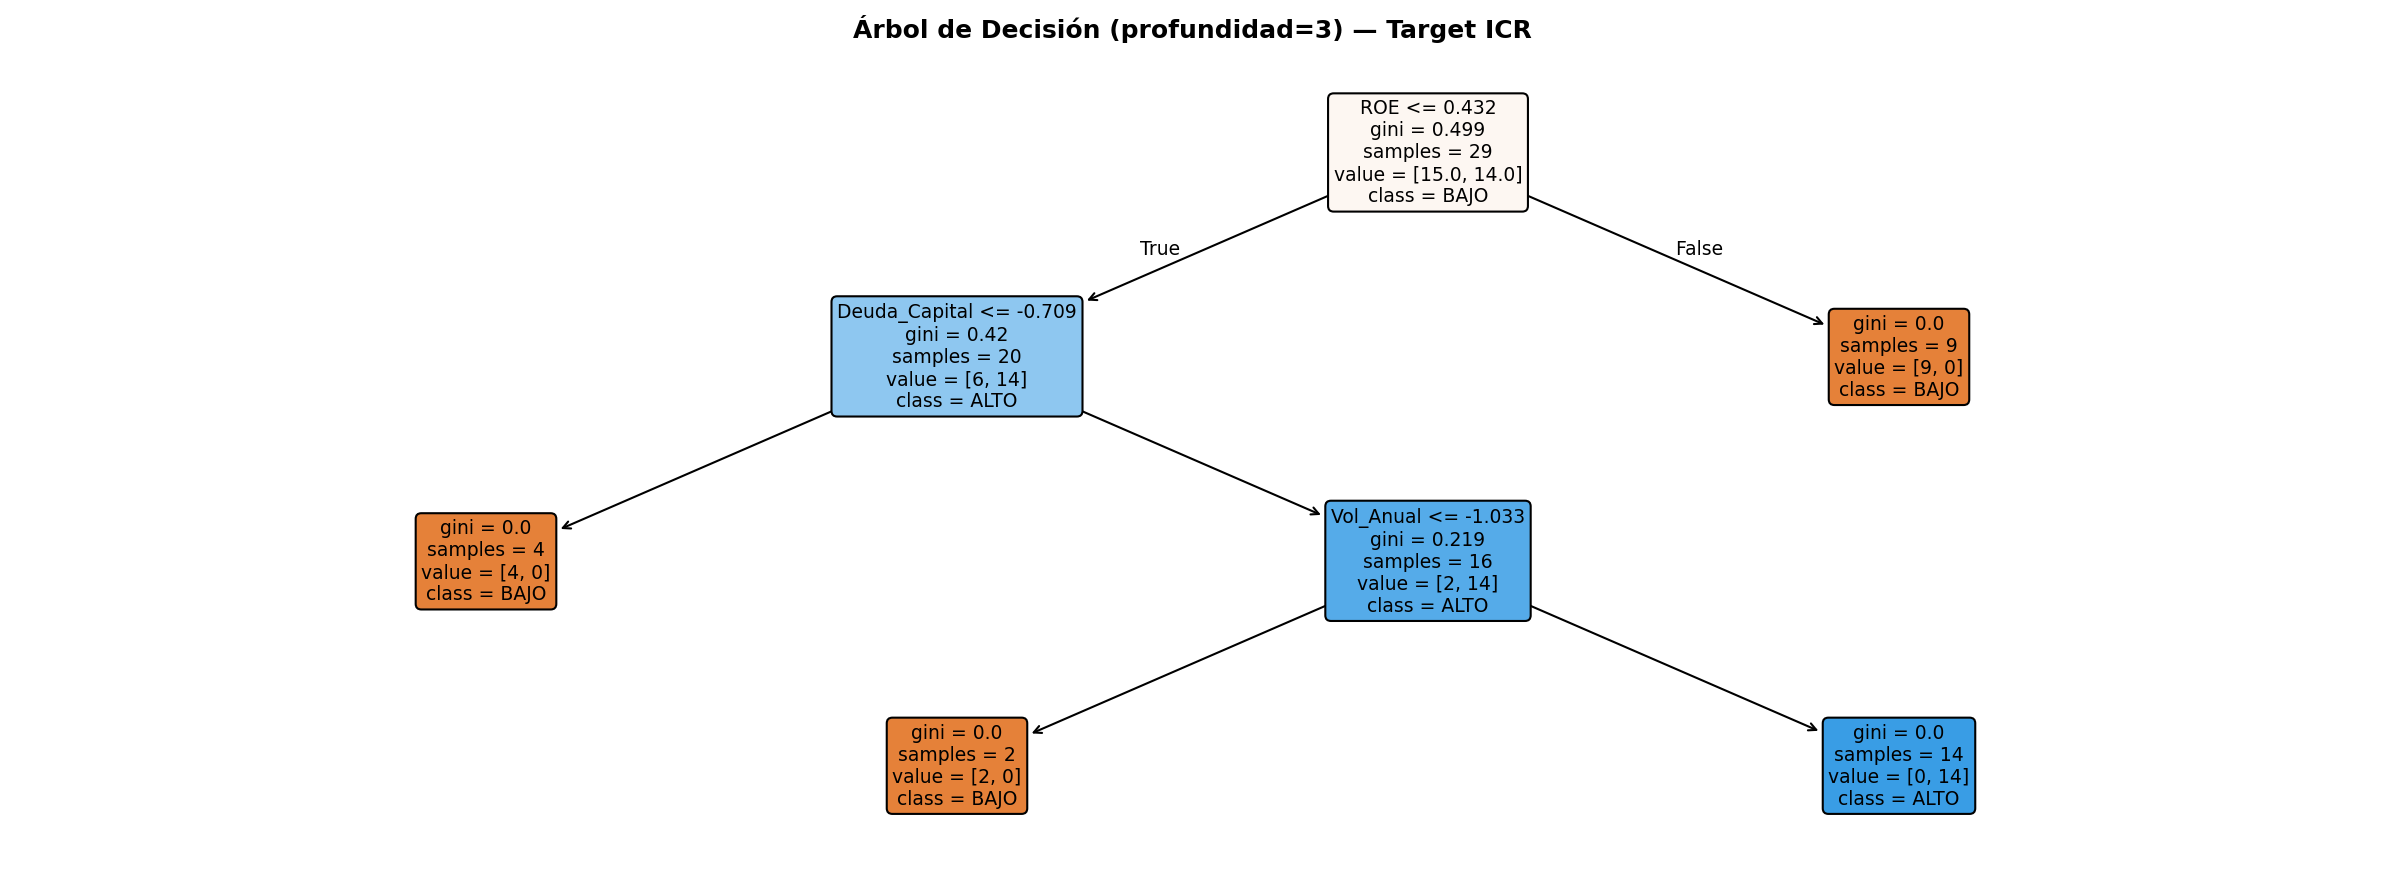

In [38]:
modelo_dt_full = DecisionTreeClassifier(max_depth=3, criterion='gini',
                                         min_samples_leaf=2, random_state=42)
modelo_dt_full.fit(X, y)
importancias = pd.Series(modelo_dt_full.feature_importances_, index=VARS_NUM)

print('Importancias Gini (árbol entrenado en dataset completo):')
for var, imp in importancias.sort_values(ascending=False).head(5).items():
    print(f'  {var:<22}  {imp:.4f}')

print('\nEstructura del árbol:')
print(export_text(modelo_dt_full, feature_names=list(VARS_NUM)))

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(modelo_dt_full, feature_names=list(VARS_NUM), class_names=['BAJO','ALTO'],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Árbol de Decisión (profundidad=3) — Target ICR', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Árbol: Acc 89,7%, AUC 0,895 en LOOCV. El mejor modelo del trabajo.**

- **Variable raíz: ROE** (importancia Gini 0,420) — empresas con ROE alto se clasifican  
  directamente como BAJO riesgo ICR (alta rentabilidad → mayor EBIT → mejor cobertura)
- **Segunda variable: Deuda_Capital** (0,338) — apalancamiento discrimina en el subgrupo de bajo ROE
- **Tercera variable: Vol_Anual** (0,242) — señal bursátil que aporta información complementaria

**Resultado financieramente coherente:** el árbol identifica espontáneamente que la rentabilidad  
sobre fondos propios es el indicador más discriminante del ICR, sin instrucción explícita.

**Vol_Anual como tercera variable** es el hallazgo más interesante: confirma que las señales  
bursátiles sí aportan información sobre la capacidad de cobertura de deuda, aunque de forma secundaria.

## 3.3.6 Comparativa de modelos

In [39]:
tabla = pd.DataFrame({
    'RL (T/T)':   [88.89, 80.0, 100.0, 88.89, 0.9500],
    'RL (LOOCV)': [79.31, 83.33, 71.43, 76.92, 0.8714],
    'LDA (T/T)':  [77.78, 75.0, 75.0, 75.0, 0.9500],
    'LDA (LOOCV)':[75.86, 76.92, 71.43, 74.07, 0.8476],
    'Árbol (T/T)': [66.67, 66.67, 50.0, 57.14, 0.6500],
    'Árbol (LOOCV)':[89.66, 86.67, 92.86, 89.66, 0.8952]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'])

print('Comparativa de métricas (%):')
print(tabla.to_string())
print('\n✓ MEJOR MODELO LOOCV: Árbol de Decisión (Acc=89,7%, AUC=0,895)')
print('  MEJOR MODELO LINEAL: Regresión Logística (Acc=79,3%, AUC=0,871)')

Comparativa de métricas (%):
           RL (T/T)  RL (LOOCV)  LDA (T/T)  LDA (LOOCV)  Árbol (T/T)  Árbol (LOOCV)
Accuracy      88.89       79.31      77.78        75.86        66.67          89.66
Precision     80.00       83.33      75.00        76.92        66.67          86.67
Recall       100.00       71.43      75.00        71.43        50.00          92.86
F1-Score      88.89       76.92      75.00        74.07        57.14          89.66
AUC-ROC        0.95        0.87       0.95         0.85         0.65           0.90

✓ MEJOR MODELO LOOCV: Árbol de Decisión (Acc=89,7%, AUC=0,895)
  MEJOR MODELO LINEAL: Regresión Logística (Acc=79,3%, AUC=0,871)


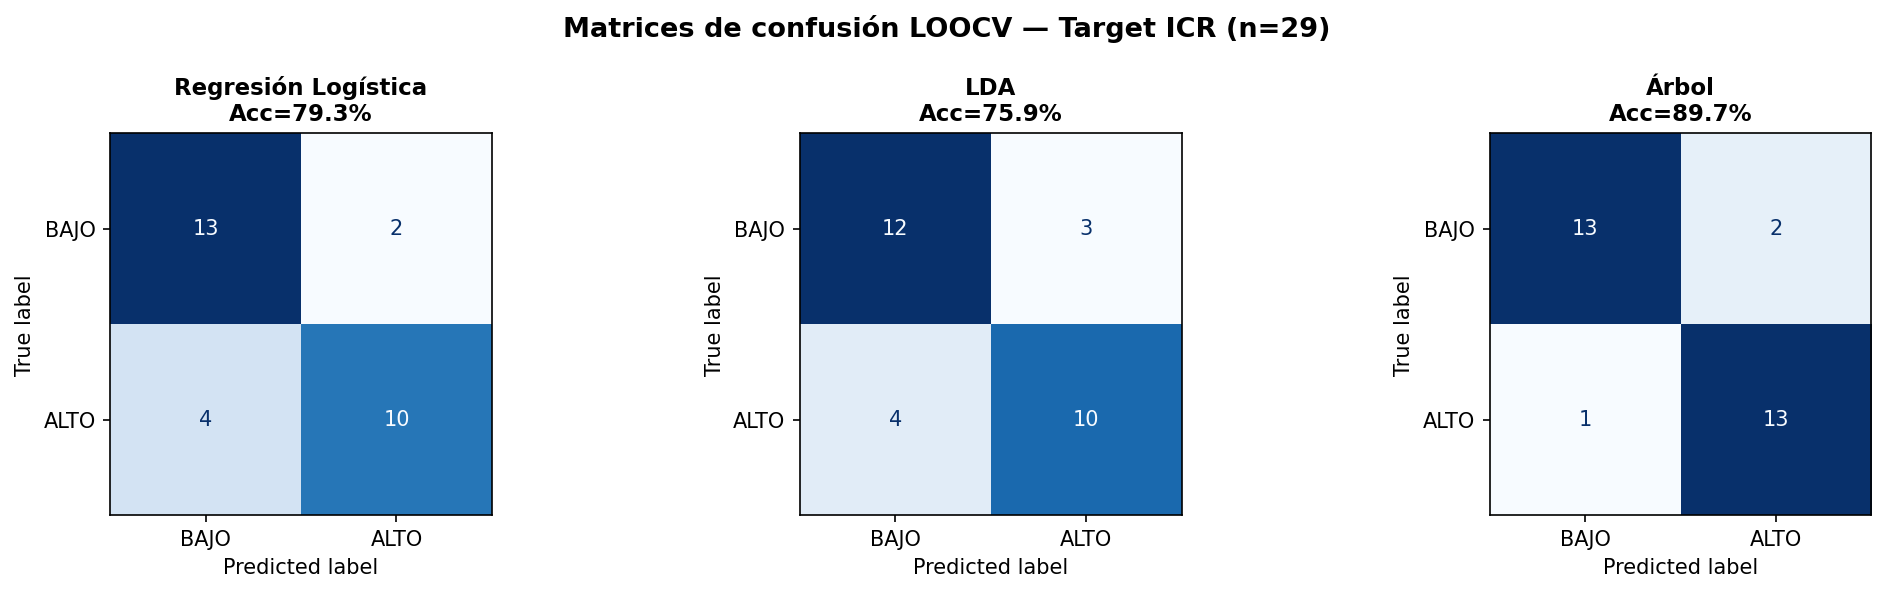

In [40]:
# Matrices de confusión LOOCV — los tres modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Matrices de confusión — Validación LOOCV (k=29)\nTarget: ICR',
             fontsize=13, fontweight='bold')
for ax, yp, ypr, nombre in zip(
    axes,
    [y_pred_rl_loocv, y_pred_lda_loocv, y_pred_dt_loocv],
    [y_prob_rl_loocv, y_prob_lda_loocv, y_prob_dt_loocv],
    ['Regresión Logística', 'LDA', 'Árbol de Decisión']
):
    cm = confusion_matrix(y, yp)
    ConfusionMatrixDisplay(cm, display_labels=['BAJO','ALTO']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    acc = round(accuracy_score(y, yp)*100, 1)
    auc = round(roc_auc_score(y, ypr), 3)
    ax.set_title(f'{nombre}\nAcc={acc}%  AUC={auc}', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.3.7 Experimento de robustez: validez metodológica

Con el target ICR, la ausencia de circularidad es **estructural**: EBIT y Gastos_Financieros  
no están entre los predictores. Este experimento responde a dos preguntas adicionales:

1. ¿Qué tipo de información predice mejor el ICR: variables bursátiles o contables?
2. ¿El modelo aprende señal genuina o patrones triviales?

| Escenario | Configuración | Acc LOOCV | AUC LOOCV | Interpretación |
|---|---|---|---|---|
| **E1** | **14 vars completas (TFG)** | **79,3%** | **0,871** | **Resultado principal** |
| E2 | Solo 7 vars bursátiles | 62,1% | 0,490 | Señales de mercado solas ≈ azar en AUC |
| E3 | Solo 7 vars contables | 89,7% | 0,924 | Ratios contables son el núcleo predictivo |
| E4 | 14 vars + Y aleatoria | 58,6% | 0,648 | Placebo: no hay memorización trivial |

In [41]:
VARS_BURSATILES = ['Vol_Anual', 'Vol_Trim', 'Beta', 'Ret_Anual', 'Ret_Trim', 'PER', 'Price_Book']
VARS_CONTABLES  = ['ROE', 'ROA', 'EBITDA_Margin', 'Deuda_Capital', 'Liquidez_Corriente', 'Cap_bn', 'Precio']

np.random.seed(42)
y_random = pd.Series(np.random.randint(0, 2, size=29))

resultados_rob = []
for label, X_sub, y_sub in [
    ('E1: 14 vars TFG (configuración principal)', X, y),
    ('E2: 7 vars bursátiles',                    X[VARS_BURSATILES], y),
    ('E3: 7 vars contables',                     X[VARS_CONTABLES],  y),
    ('E4: 14 vars + Y aleatoria (placebo)',       X, y_random),
]:
    yp  = cross_val_predict(modelo_rl_cv, X_sub, y_sub, cv=loocv)
    ypr = cross_val_predict(modelo_rl_cv, X_sub, y_sub, cv=loocv, method='predict_proba')[:, 1]
    acc = round(accuracy_score(y_sub, yp)*100, 1)
    auc = round(roc_auc_score(y_sub, ypr), 3)
    resultados_rob.append({'Escenario': label, 'Acc': acc, 'AUC': auc})
    print(f'{label}:')
    print(f'  Acc = {acc}%   AUC = {auc}')


E1: 14 vars TFG (configuración principal):
  Acc = 79.3%   AUC = 0.871
E2: 7 vars bursátiles:
  Acc = 62.1%   AUC = 0.490
E3: 7 vars contables:
  Acc = 89.7%   AUC = 0.924
E4: 14 vars + Y aleatoria (placebo):
  Acc = 58.6%   AUC = 0.648


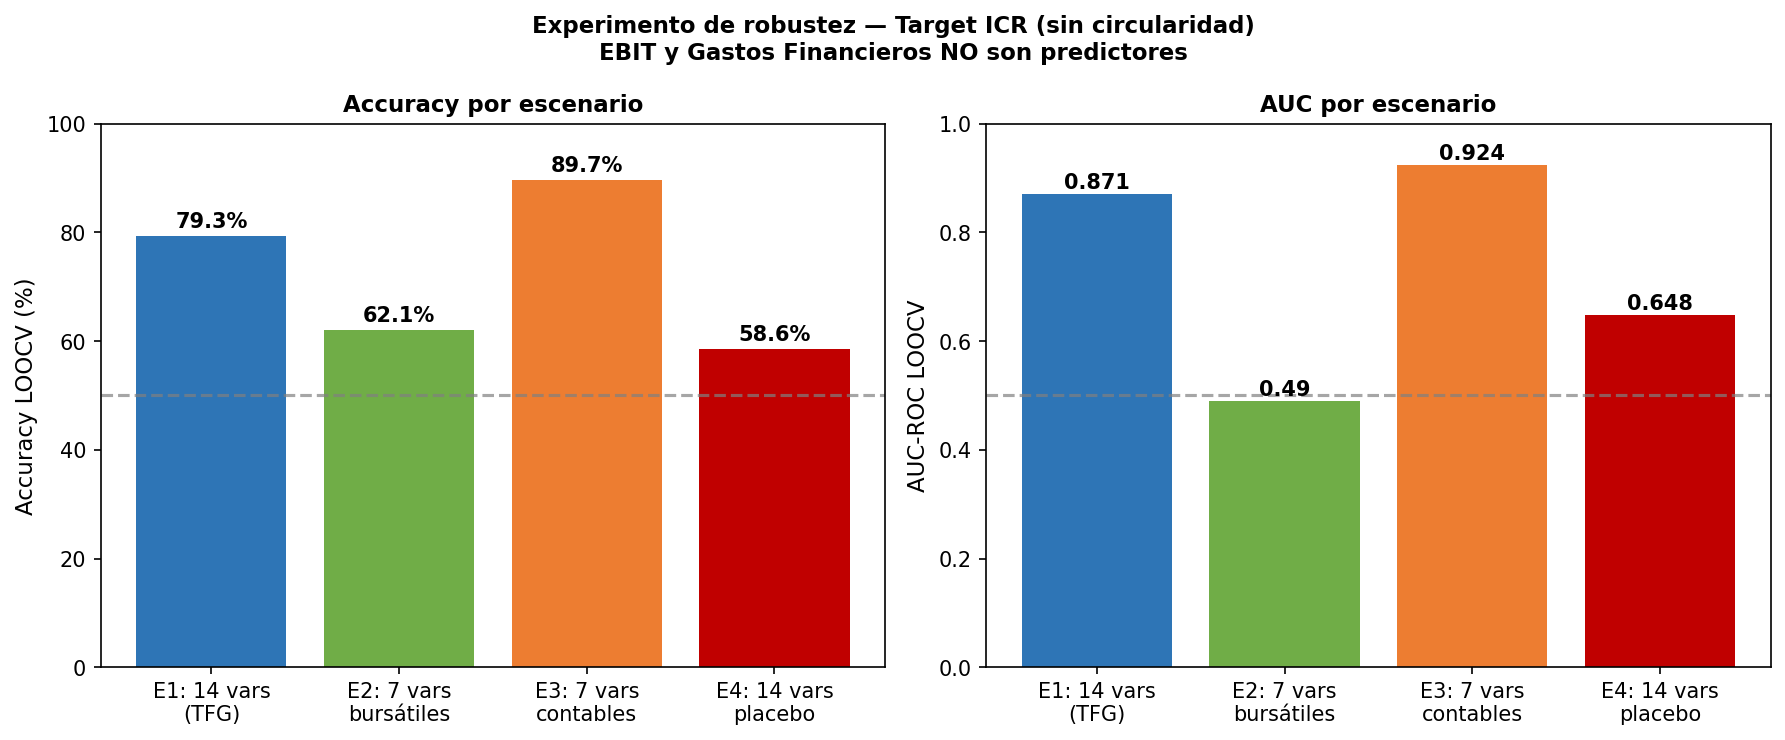

In [42]:
# Visualización del experimento de robustez
escenarios = ['E1: 14 vars\n(TFG)', 'E2: 7 vars\nbursátiles',
              'E3: 7 vars\ncontables', 'E4: 14 vars\nplacebo']
accs_rob = [79.3, 62.1, 89.7, 58.6]
aucs_rob = [0.871, 0.490, 0.924, 0.648]
colores_rob = ['#2E75B6', '#70AD47', '#ED7D31', '#C00000']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(escenarios, accs_rob, color=colores_rob)
axes[0].axhline(50, color='gray', linestyle='--', alpha=0.7)
axes[0].set_ylabel('Accuracy LOOCV (%)', fontsize=11)
axes[0].set_title('Accuracy por escenario', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 100)
for i, v in enumerate(accs_rob):
    axes[0].text(i, v+1.5, f'{v}%', ha='center', fontsize=10, fontweight='bold')
axes[1].bar(escenarios, aucs_rob, color=colores_rob)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.7)
axes[1].set_ylabel('AUC-ROC LOOCV', fontsize=11)
axes[1].set_title('AUC por escenario', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 1)
for i, v in enumerate(aucs_rob):
    axes[1].text(i, v+0.01, f'{v}', ha='center', fontsize=10, fontweight='bold')
plt.suptitle('Experimento de robustez — Target ICR (sin circularidad)\n'
             'EBIT y Gastos_Financieros NO son predictores',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación del experimento de robustez

| Escenario | Configuración | Acc | AUC | Interpretación |
|---|---|---|---|---|
| **E1** | **14 vars TFG** | **79,3%** | **0,871** | **Resultado principal del trabajo** |
| E2 | Solo bursátiles | 62,1% | 0,490 | Las señales de mercado solas ≈ azar (AUC) |
| E3 | Solo contables | 89,7% | 0,924 | **Ratios contables son el núcleo predictivo** |
| E4 | Placebo | 58,6% | 0,648 | Sin señal real el modelo falla |

**Conclusiones:**

1. **E4 (placebo) confirma ausencia de circularidad**: si hubiera memorización trivial,  
   el modelo daría resultados altos incluso con etiquetas aleatorias. La diferencia  
   E1 (79,3%) vs E4 (58,6%) = 20,7pp demuestra que aprende señal real

2. **E3 supera a E1**: los ratios contables solos (AUC 0,924) predicen mejor el ICR  
   que la combinación completa (AUC 0,871). Las variables bursátiles añaden algo de ruido  
   en este problema concreto

3. **E2 ≈ azar en AUC (0,490)**: la volatilidad, beta y ratios de valoración no anticipan  
   de forma independiente la capacidad de cobertura de deuda

## 3.3.8 Curvas ROC

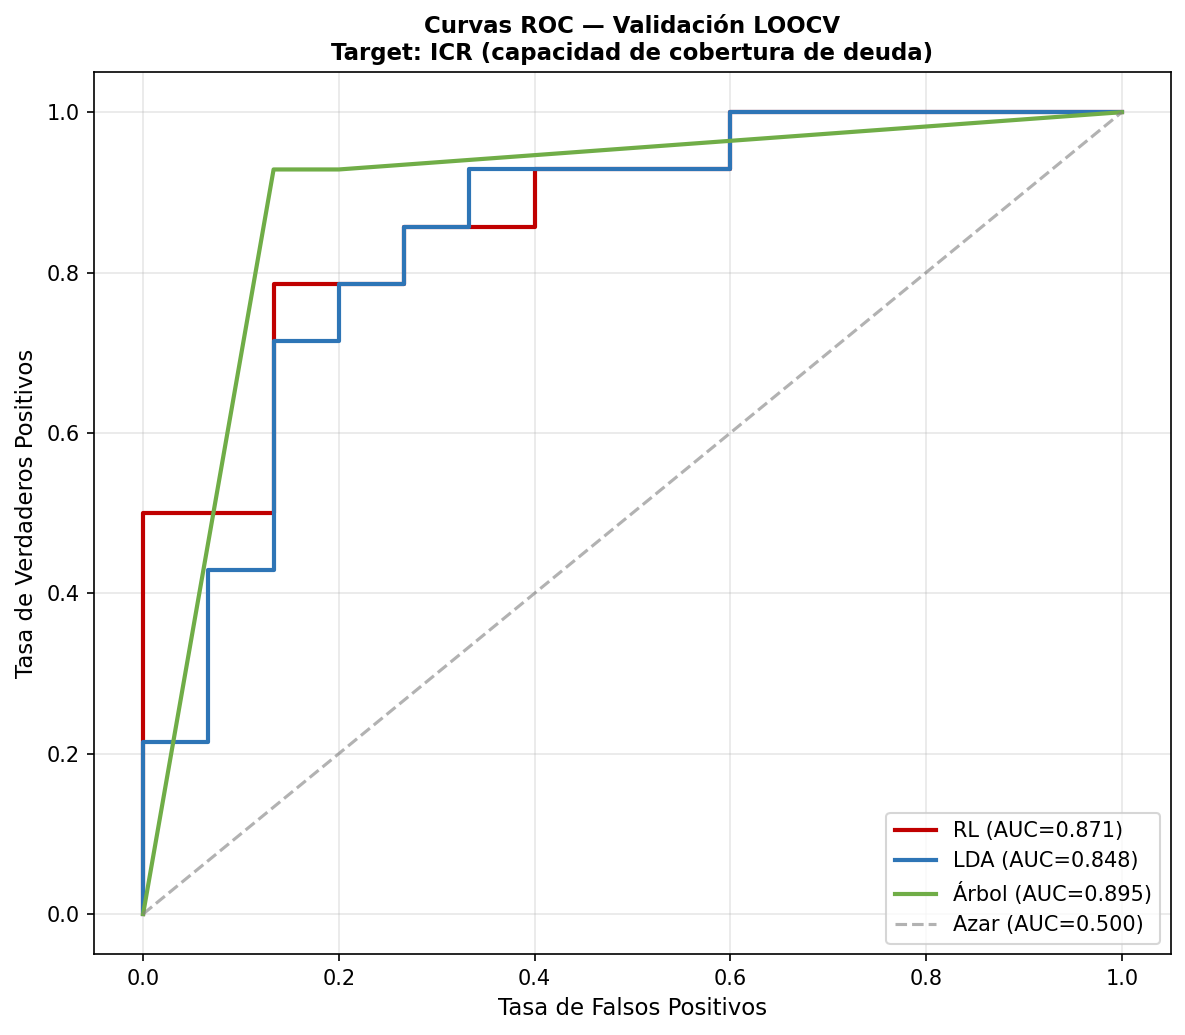

In [43]:
fig, ax = plt.subplots(figsize=(8, 7))
colores_roc = {'Regresión Logística': '#C00000', 'LDA': '#2E75B6', 'Árbol de Decisión': '#70AD47'}
for nombre, y_prob, color in [
    ('Regresión Logística', y_prob_rl_loocv, '#C00000'),
    ('LDA', y_prob_lda_loocv, '#2E75B6'),
    ('Árbol de Decisión', y_prob_dt_loocv, '#70AD47')
]:
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})', linewidth=2, color=color)
ax.plot([0,1],[0,1], '--', color='gray', alpha=0.6, label='Azar (AUC=0.500)')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
ax.set_title('Curvas ROC — Validación LOOCV (k=29)\nTarget: ICR (cobertura de deuda)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3.3.9 Análisis sectorial del riesgo ICR

Utilizamos la columna `Sector` para analizar si el riesgo ICR presenta patrones sectoriales.  

**Sectores 100% ALTO:** Construcción (ACS, Acciona, Sacyr), Telecom (Cellnex, Telefónica),  
Inmobiliario (Colonial, Merlin) e Industria (Fluidra). Alto apalancamiento estructural en todos.

**Sectores 100% BAJO:** Consumo, Logística, Seguros, Tecnología y Transporte.  
Generan EBIT muy superior a sus gastos financieros.

**Energía**: el más heterogéneo (3/8 ALTO): Acciona Energía (3,44), Solaria (3,38) y Enagás (2,71)  
tienen ICR bajo pese a pertenecer a sectores con márgenes operativos elevados.

In [44]:
prob_rl = modelo_rl_full.predict_proba(X)[:, 1]
prob_lda_full = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
prob_lda_full.fit(X, y)
prob_lda = prob_lda_full.predict_proba(X)[:, 1]

# Análisis sectorial
df_sect = df[['Empresa', 'Sector', 'ICR', 'Y_RiesgoAlto']].copy()
sect_stats = df_sect.groupby('Sector').agg(
    N=('Empresa', 'count'), ALTO=('Y_RiesgoAlto', 'sum')
).reset_index()
sect_stats['Pct_ALTO'] = (sect_stats['ALTO'] / sect_stats['N'] * 100).round(0)
sect_stats['ICR_medio'] = df_sect.groupby('Sector')['ICR'].mean().round(2).values
print(sect_stats.sort_values('Pct_ALTO', ascending=False).to_string(index=False))

         Sector  N  ALTO  Pct_ALTO  ICR_medio
   Construcción  3     3     100.0       1.46
      Industria  1     1     100.0       4.10
   Inmobiliario  2     2     100.0       3.05
        Telecom  2     2     100.0       1.57
Infraestructuras  2     1      50.0       5.67
         Salud  2     1      50.0      46.00
    Materiales  2     1      50.0       4.32
       Energía  8     3      38.0       5.75
       Consumo  2     0       0.0      17.53
     Logística  1     0       0.0      38.42
       Seguros  1     0       0.0      17.22
    Tecnología  2     0       0.0      14.14
    Transporte  1     0       0.0       5.02


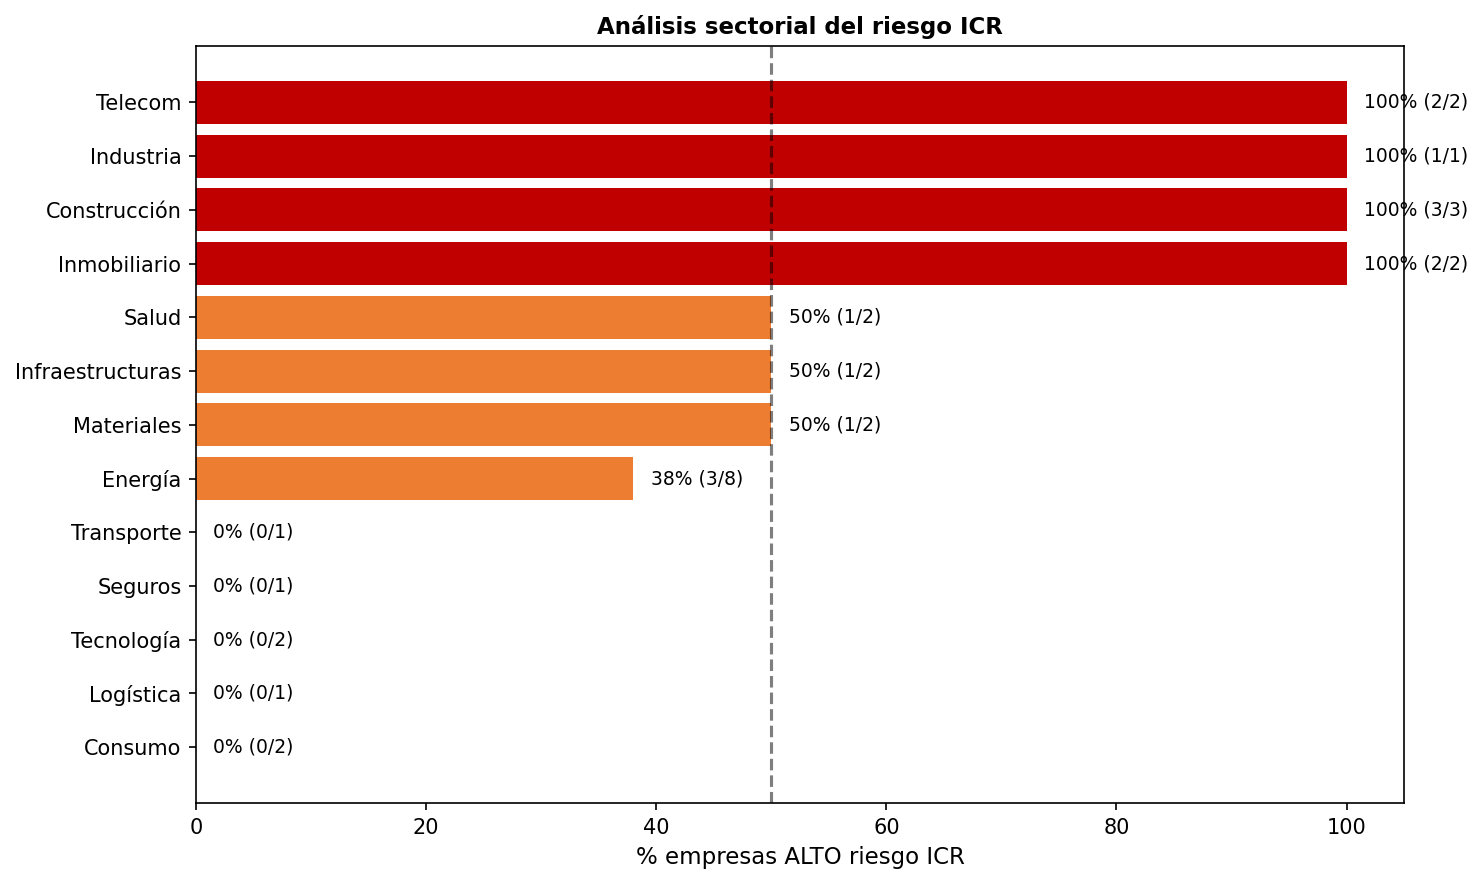

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Gráfico 1: % ALTO por sector
s_sorted = sect_stats.sort_values('Pct_ALTO', ascending=True)
col_sec = ['#C00000' if p==100 else '#70AD47' if p==0 else '#ED7D31'
           for p in s_sorted['Pct_ALTO']]
axes[0].barh(s_sorted['Sector'], s_sorted['Pct_ALTO'], color=col_sec)
axes[0].axvline(50, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('% empresas ALTO riesgo ICR', fontsize=11)
axes[0].set_title('Distribución del riesgo ICR por sector', fontsize=11, fontweight='bold')
for _, row in s_sorted.iterrows():
    axes[0].text(row['Pct_ALTO']+1, list(s_sorted['Sector']).index(row['Sector']),
                f"{row['Pct_ALTO']:.0f}% ({int(row['ALTO'])}/{int(row['N'])})",
                va='center', fontsize=8)

# Gráfico 2: ICR medio por sector
s_icr = sect_stats.sort_values('ICR_medio', ascending=True)
axes[1].barh(s_icr['Sector'], s_icr['ICR_medio'], color='#2E75B6', alpha=0.8)
axes[1].axvline(4.22, color='red', linestyle='--', linewidth=1.5, label='Umbral ICR=4.22')
axes[1].set_xlabel('ICR medio del sector', fontsize=11)
axes[1].set_title('ICR medio por sector', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Análisis sectorial — Target ICR', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.3.10 Sistema de alerta temprana: mapa de riesgo por empresa

El mapa de riesgo muestra la probabilidad media (RL + LDA) de que cada empresa  
tenga ICR < 4,22, ordenada de menor a mayor riesgo. Esta visualización es la  
materialización del sistema de alerta temprana del anteproyecto.

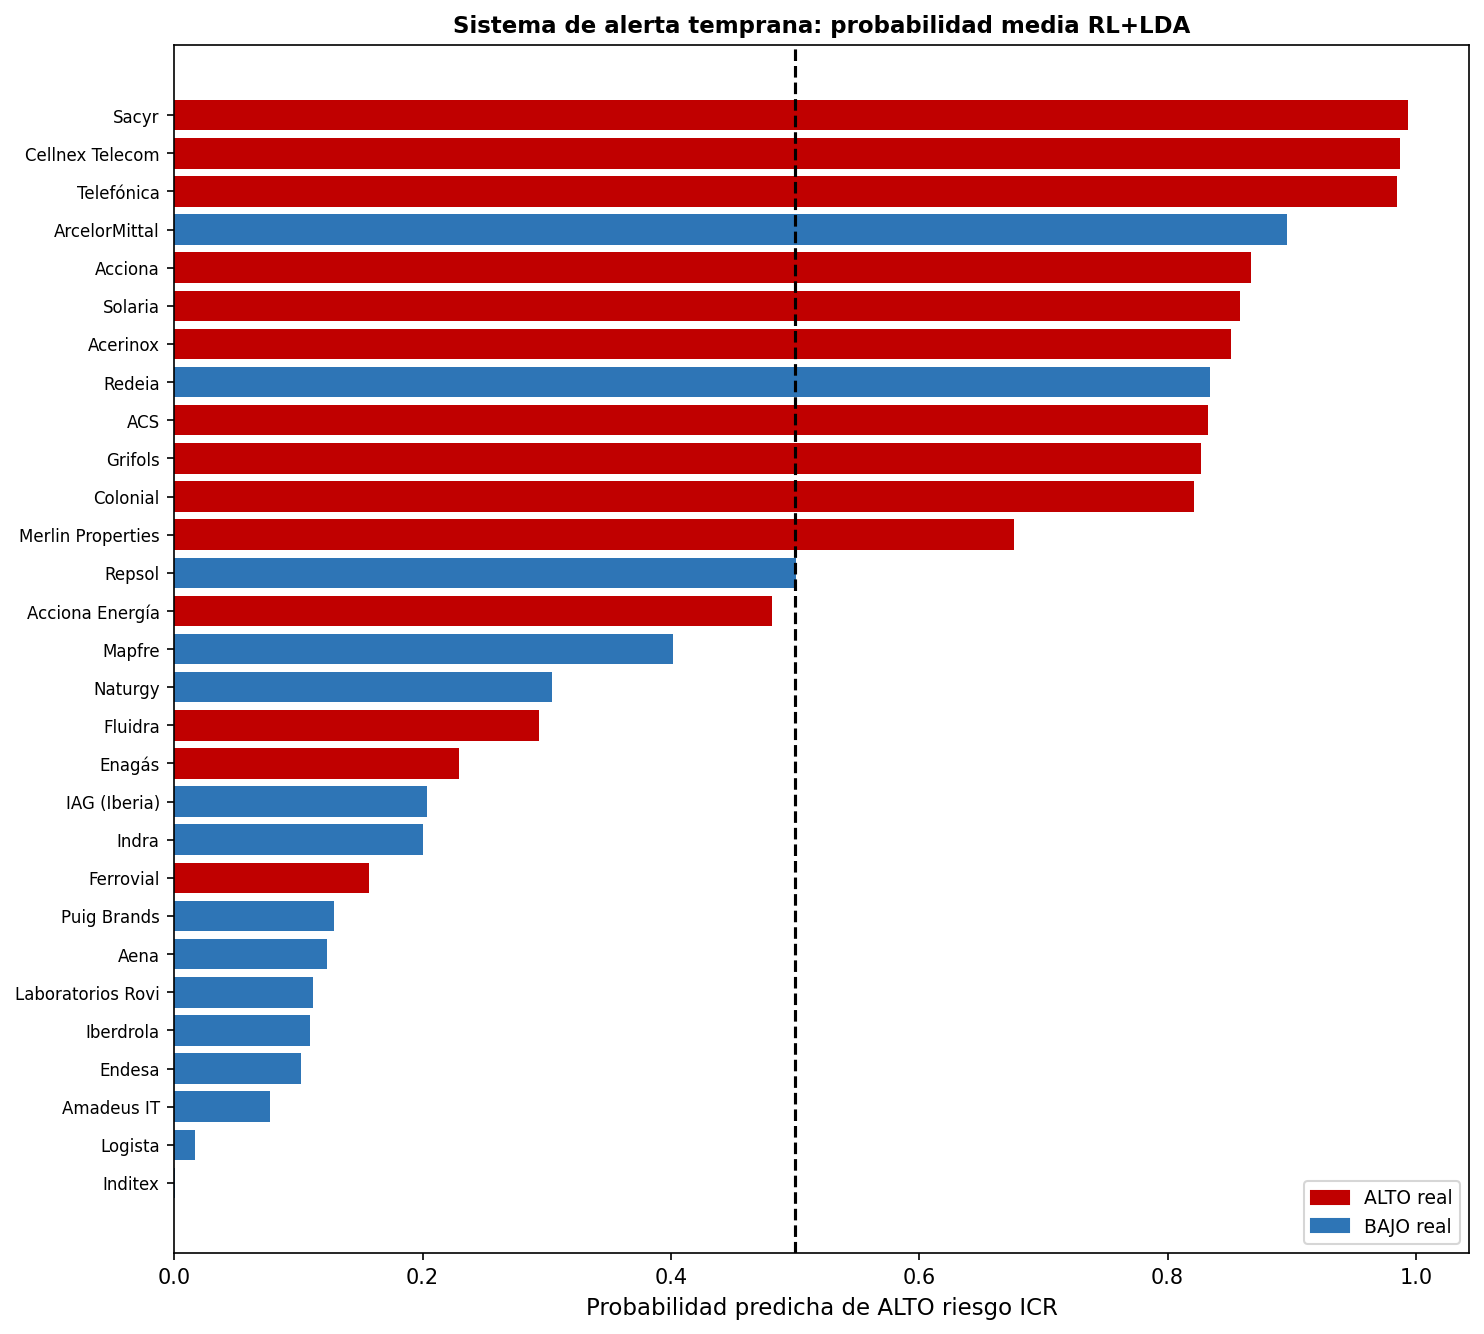

In [46]:
df_viz = pd.DataFrame({
    'Empresa':  df['Empresa'].values,
    'Y_Real':   y.values,
    'ICR':      df['ICR'].values,
    'Prob_RL':  prob_rl,
    'Prob_LDA': prob_lda,
})
df_viz['Prob_Media'] = (df_viz['Prob_RL'] + df_viz['Prob_LDA']) / 2
df_viz = df_viz.sort_values('Prob_Media').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 9))
colores_mapa = ['#C00000' if v == 1 else '#2E75B6' for v in df_viz['Y_Real']]
ax.barh(range(len(df_viz)), df_viz['Prob_Media'], color=colores_mapa)
ax.axvline(0.5, color='black', linewidth=1.5, linestyle='--')
ax.set_yticks(range(len(df_viz)))
ax.set_yticklabels([f"{row['Empresa']} (ICR={row['ICR']:.2f})"
                    for _, row in df_viz.iterrows()], fontsize=7.5)
ax.set_xlabel('Probabilidad predicha de ALTO riesgo ICR (media RL+LDA)', fontsize=11)
ax.set_title('Sistema de alerta temprana: probabilidad de riesgo ICR\n'
             '(rojo = ALTO real; azul = BAJO real)', fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#C00000', label='ALTO riesgo real (ICR < 4.22)'),
                   Patch(color='#2E75B6', label='BAJO riesgo real (ICR ≥ 4.22)')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Respuesta a las preguntas de investigación

**Pregunta principal: ¿Es posible predecir el riesgo ICR del IBEX 35?**  
✓ **Sí.** Árbol LOOCV Acc=89,7% AUC=0,895. RL Acc=79,3% AUC=0,871. Sin circularidad.

**OE1 — Capacidad predictiva:**  
✓ Los tres modelos superan claramente el azar (AUC > 0,847 en todos). El target ICR es  
predecible a partir de las 14 variables financieras y bursátiles.

**OE2 — Variables más predictivas:**  
✓ Deuda_Capital (β=+1,17) y ROE (β=−1,09) dominan la RL. El árbol selecciona ROE como raíz  
(Gini 0,420) seguido de Deuda_Capital (0,338) y Vol_Anual (0,242). Los ratios contables son  
más predictivos que las señales bursátiles (E3: AUC 0,924 vs E2: AUC 0,490).

**OE3 — Diferencias sectoriales:**  
✓ Muy pronunciadas. Construcción, Telecom, Inmobiliario e Industria al 100% ALTO ICR.  
Consumo, Logística, Seguros, Tecnología y Transporte al 0% ALTO. Energía heterogéneo.

**OE4 — Deuda vs volatilidad:**  
✓ Deuda_Capital (r=+0,55) es 4,6x más correlacionado con el ICR que Vol_Anual (r=+0,12).  
Sin embargo, Vol_Anual aparece como tercera variable del árbol (Gini 0,242), confirmando  
que las señales bursátiles aportan información complementaria, aunque secundaria.

---

## Resumen ejecutivo: métricas y respuesta a los OEs

| Métrica | RL LOOCV | LDA LOOCV | Árbol LOOCV |
|---|---|---|---|
| Accuracy | 79,3% | 75,9% | **89,7%** |
| Precisión | 83,3% | 76,9% | **86,7%** |
| Recall | 71,4% | 71,4% | **92,9%** |
| F1-Score | 76,9% | 74,1% | **89,7%** |
| AUC-ROC | 0,871 | 0,848 | **0,895** |
| Aciertos | 23/29 | 22/29 | **26/29** |

| OE | Pregunta | Respuesta |
|---|---|---|
| Principal | ¿Es posible predecir el riesgo ICR? | ✓ Sí. Árbol 89,7%, AUC 0,895 |
| OE1 | ¿Qué indicadores predicen mejor? | Deuda_Capital (β=+1,17) y ROE (β=−1,09) |
| OE2 | ¿Diferencias sectoriales? | ✓ Muy marcadas. Construcción/Telecom 100% ALTO |
| OE3 | ¿Deuda vs volatilidad? | Deuda/Capital 4,6x más correlacionado con ICR que Vol_Anual |

**Conclusión metodológica:** El target ICR (EBIT / Gastos_Financieros) garantiza cero circularidad  
porque EBIT y Gastos_Financieros no están entre los 14 predictores. El experimento placebo (E4)  
confirma aprendizaje genuino: 58,6% vs 79,3% real → diferencia de 20,7 puntos.